# Titanic Data Analysis
* *Goal: Investigating survival patterns and preparing data for ML*

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Titanic_Train.csv')
print('--Data Load---')

--Data Load---


In [110]:
#Inital inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [128]:
#Checking the dataset via describe
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208,1.904602
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429,1.613459
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,1.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,2.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


In [111]:
#Checking for missing values 
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

There are a lot of missing values in the column 'Cabin'. Which cannot be filled with mean or other values. So I decide to drop the column

In [112]:
#deleting the column 'Cabin' because there are a total of 687 missing values. 
df.drop(columns=['Cabin'], inplace=True)
#checking for the result
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


In [113]:
#as there are 177 missing values in the 'Age' column - I decide to fill the missing 
#values with the median 
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

#checking for the result
print(df['Age'].describe())

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


In [114]:
#adding a new column ('isChild') to the df to check if there are persons under 18
df['isChild'] = df['Age'] < 18
#checking the columns
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'isChild'],
      dtype='object')


In [115]:
#adding another new column ('FamilySize) by summarising the columns 'SibSp' and 'Parch'
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1 
#+1 because of the person itself
#checking the columns
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'isChild', 'FamilySize'],
      dtype='object')


### First Visualizaions after checking the data set and adding two new columns

*Note: I am focusing on clear, interpretable visualizations first to build a solid foundation before moving into more complex statistical plots.*

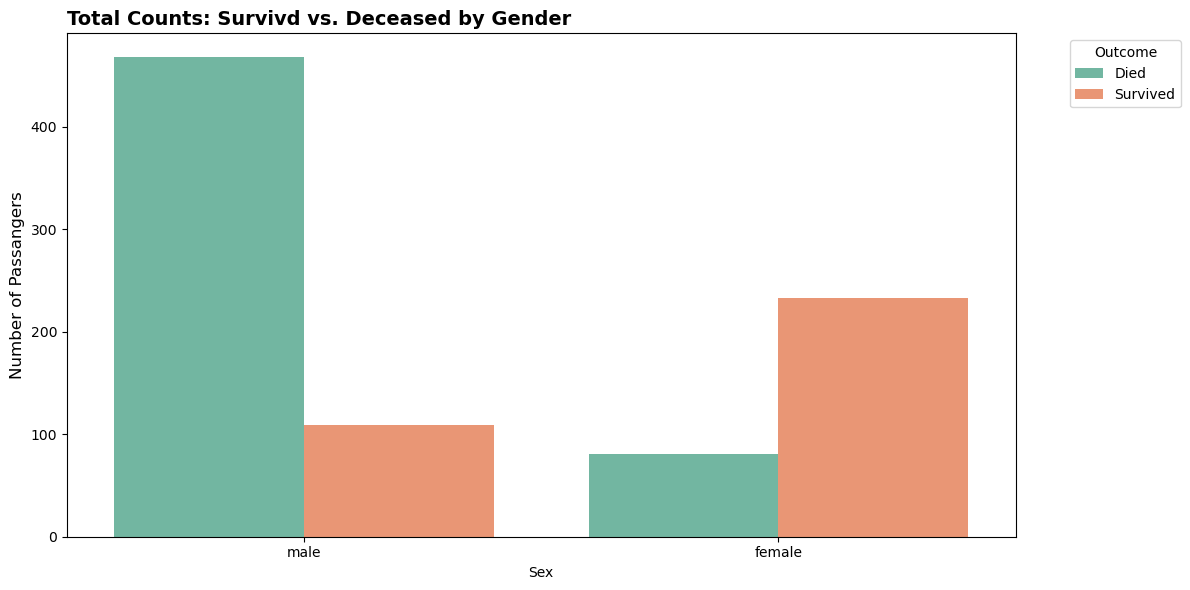

In [ ]:
#visualize count of passengers by sex and survivial
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Sex', hue='Survived', palette='Set2')
plt.title('Total Counts: Survivd vs. Deceased by Gender', fontsize=14, fontweight='bold', loc='left')
plt.ylabel('Number of Passangers', fontsize=12)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='Outcome', labels=['Died', 'Survived'])

plt.tight_layout()
plt.show()

The chart reveals that more female passangers where saved, while nearly every male passenger died. Over 400 male passengers were not be able to get into a life boat and died. Round about 100 male passengers survived. This clearly shows, the regulation on board, for female and children first before other passengers. *I choose a simple countplot to visualize the raw numbers of the gender gap.*

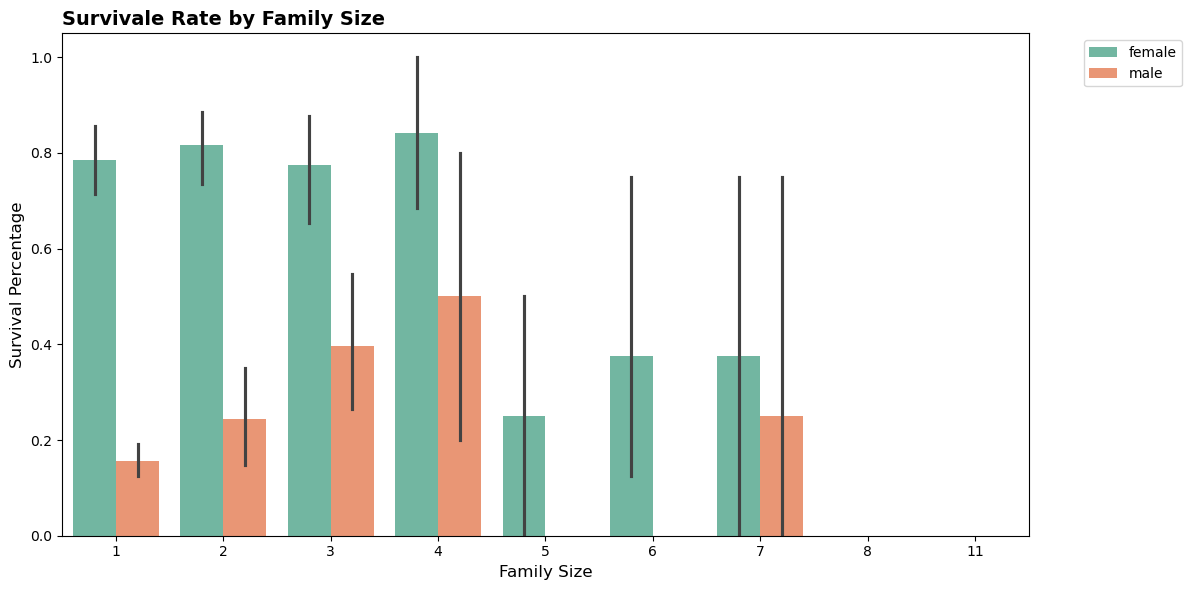

In [117]:
#visulize of survival rate by family size
plt.figure(figsize=(12,6))

sns.barplot(data=df, x='FamilySize', y='Survived', hue='Sex', palette='Set2')
plt.title('Survivale Rate by Family Size', fontsize=14, fontweight='bold', loc='left')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.xlabel('Family Size', fontsize=12)
plt.ylabel('Survival Percentage', fontsize=12)

plt.tight_layout()
plt.show()

The chart reveals a significant disparity between female and male survival rate. Mostly female where saved, while male in a family size of 5 and 6 did not survied

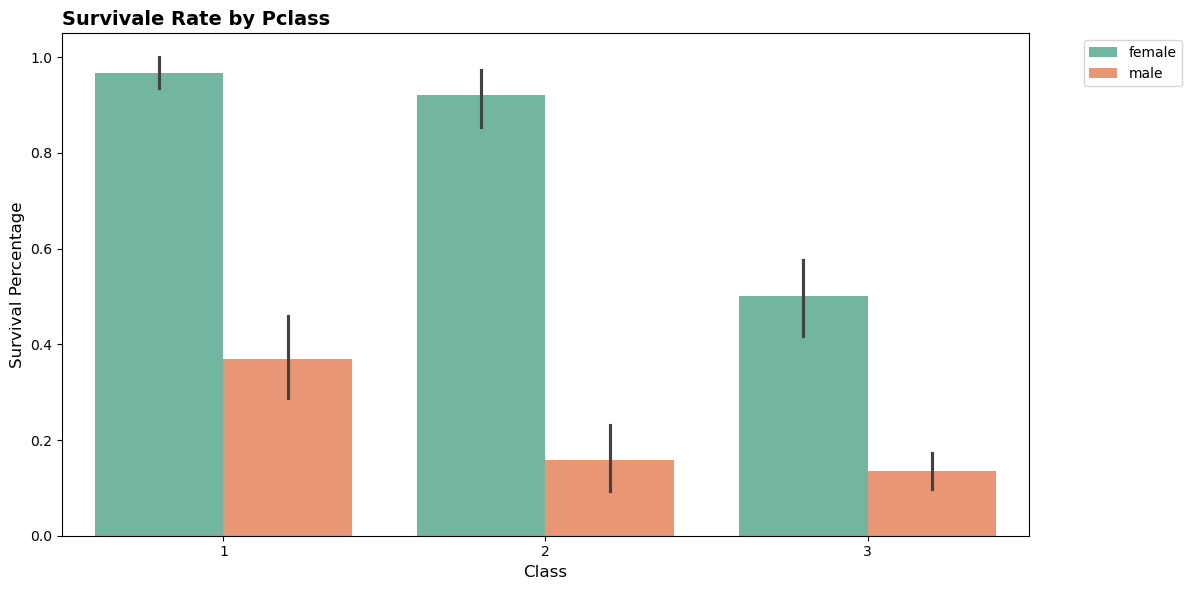

In [118]:
#visualize of survival rate by Pclass
plt.figure(figsize=(12,6))

sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', palette='Set2')
plt.title('Survivale Rate by Pclass', fontsize=14, fontweight='bold', loc='left')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Survival Percentage', fontsize=12)

plt.tight_layout()
plt.show()

This analysis reveals that almost all female passengers from first and second class survived. And also more than 50% of the third class of female passangers. However, not even 50% of the male passengers in any kind of class survived. This chart confirms that female passengers had a higher safety priority regardless of their class.

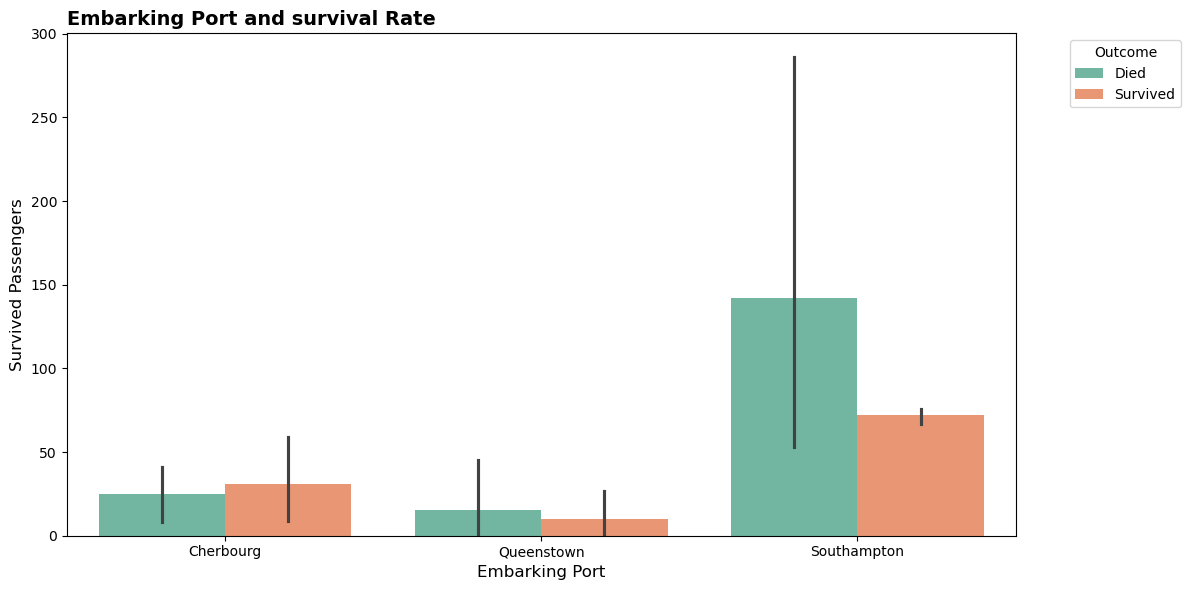

       Embarked  Survived  Pclass  PassengerId
0     Cherbourg      Died       1           26
1     Cherbourg      Died       2            8
2     Cherbourg      Died       3           41
3     Cherbourg  Survived       1           59
4     Cherbourg  Survived       2            9
5     Cherbourg  Survived       3           25
6    Queenstown      Died       1            1
7    Queenstown      Died       2            1
8    Queenstown      Died       3           45
9    Queenstown  Survived       1            1
10   Queenstown  Survived       2            2
11   Queenstown  Survived       3           27
12  Southampton      Died       1           53
13  Southampton      Died       2           88
14  Southampton      Died       3          286
15  Southampton  Survived       1           74
16  Southampton  Survived       2           76
17  Southampton  Survived       3           67


In [120]:
#Analyse if there is a context between embarking port, class and survival rate
embarked_det = df.groupby(['Embarked', 'Survived', 'Pclass'])['PassengerId'].count().reset_index()
#Replacing the abbreviations 
embarked_det['Survived'] = embarked_det['Survived'].replace({0: 'Died', 1:'Survived'})
embarked_det['Embarked'] = embarked_det['Embarked'].replace({'C':'Cherbourg', 'Q':'Queenstown', 'S':'Southampton'})

plt.figure(figsize=(12,6))
sns.barplot(data=embarked_det, x='Embarked', y='PassengerId', hue='Survived', palette='Set2')
plt.title('Embarking Port and survival Rate', fontsize=14, fontweight='bold', loc='left')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='Outcome')
plt.xlabel('Embarking Port', fontsize=12)
plt.ylabel('Survived Passengers', fontsize=12)

plt.tight_layout()
plt.show()
print(embarked_det)

The chart reveals that most of the passengers embarked in Southampoton and also most of the Southampton passengers died. While Cherbourg shows a higher survival rate then passengers who died from Cherbourg. Cherbourg is the only embarking port, where the survival rate is higher then the non-survival rate. Taking a deeper look into the pclass aswell it indicates, that passengers from Queenstown are more in the third pclass while there was a higher surivival rate from Cherbourg first class passengers. 

In [129]:
#the fare columns shows a huge difference between min and max values
#i will analyse that through a boxplot chart to check the range of the fare values
print(df['Fare'].describe())

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


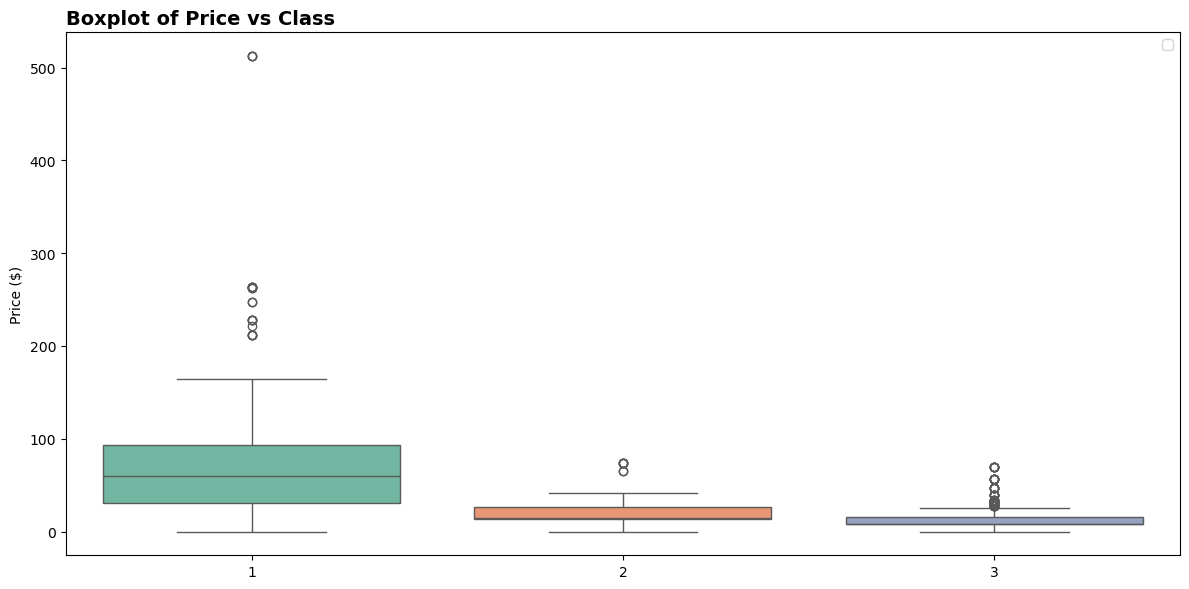

In [144]:
#visualise the fare values and the pclass in a boxplot chart
plt.figure(figsize=(12,6))

sns.boxplot(data=df, y='Fare', x='Pclass', hue='Pclass', palette='Set2')
plt.title('Boxplot of Price vs Class', fontsize=14, fontweight='bold', loc='left')
plt.xlabel('')
plt.ylabel('Price ($)')
plt.legend('')

plt.tight_layout()
plt.show()

The Boxplot reveals that there is mostly a standard price for fare tickes in the thrid class and as well in the second class. The is not realy a huge price range in the third and second class, because the box is really small which indicates that all passengers in the second and third class nearly pays the same price. A few tickets are higher which might be due to last minute bookings. The boxplot of the first class shows a higher price gap and as well some prices over 500$ which indicates the difference between the mean and the median. The price range for the first class fares is higher, which means there are a lot of different prices for passengers in the first class up to 500$